# Introduction
In an earlier datascraping project, I mentioned how the Pokemon video games--particularly Generation IV--played a big role in my childhood. As a result, I decided to create a project revolving around breaking down the Pokemon and their types in the Sinnoh region. This project will build upon that earlier project and compare the types of every Pokemon from the first five generations of Pokemon games in order to figure out the most common type amongst Pokemon in each region and compare the type distribution of each region. This means we'll be looking at all six-hundred forty-nine Pokemon from the Kanto, Johto, Hoenn, Sinnoh, and Unova regions.

# Data
The data for this analysis was sourced from the PokéAPI, covering Pokémon IDs 1 through 649 (Kanto to Unova). Each entry includes the Pokémon's ID, Name, Region (derived from the ID range), and its Primary and Secondary types.

Our project revolves around two concepts.

- **Type Unpivoting**: Since a Pokémon can have up to two types, the data required unpivoting (melting). The primary_type and secondary_type columns were stacked into a single, unified Type column. This ensures that every type assignment contributes equally to the total count, regardless of whether it was primary or secondary. Any missing secondary types were dropped to maintain data integrity.

- **Crosstabulation & Normalization**: The unpivoted data was transformed into a matrix using Pandas' crosstab(). This matrix was normalized by row (normalize='index'). This crucial step converts the raw counts into proportions, where the sum of all type percentages within any single region (row) equals 100%. This allows for a fair, normalized comparison between regions of different sizes.

In [8]:
import requests
from requests import get
from pandas import * 
from numpy import *

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
pokemon_dict = []

def get_region_from_id(pokemon_id):
    """Maps a Pokémon ID to its corresponding region (Generation)."""
    if 1 <= pokemon_id <= 151:
        return "Kanto"
    elif 152 <= pokemon_id <= 251:
        return "Johto"
    elif 252 <= pokemon_id <= 386:
        return "Hoenn"
    elif 387 <= pokemon_id <= 493:
        return "Sinnoh"
    elif 494 <= pokemon_id <= 649:
        return "Unova"

for i in range(1, 650):
    try:
        # Part 1: Get the URL for each pokemon
        url = f"https://pokeapi.co/api/v2/pokemon/{i}/"
        r = get(url)
        r.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
        data = r.json()
        
        # Part 2: Extracting data and adding region
        name = data["name"]
        
        # Determine the region using the helper function
        region = get_region_from_id(i)
        
        types = [t["type"]["name"] for t in data["types"]]
        
        # Part 2.5: Adding primary and secondary types
        primary_type = types[0] if len(types) > 0 else None
        secondary_type = types[1] if len(types) > 1 else None
        
        # Part 3: Adding them to our pokemon_dict list
        pokemon_dict.append({
            "id": i, # Added for clarity and use in the helper function
            "name": name,
            "region": region,
            "primary_type": primary_type,
            "secondary_type": secondary_type
        })
        
    except requests.exceptions.RequestException as e:
        print(f"Could not retrieve data for Pokémon ID {i}: {e}")
        continue # Skip to the next Pokémon
        
print(f"Successfully collected data for {len(pokemon_dict)} Pokémon.")

Successfully collected data for 649 Pokémon.


In [3]:
df = DataFrame(pokemon_dict)
df_indexed = df.set_index('id')
df_indexed.to_csv('pokemon_types.csv')

In [4]:
# primary types dataframe
primary_temp = df[['region', 'primary_type']].rename(columns={'primary_type': 'Type'})

# secondary types dataframe
secondary_temp = df[['region', 'secondary_type']].rename(columns={'secondary_type': 'Type'})
secondary_temp = secondary_temp.dropna(subset=['Type']) # Filter out the empty values

# stacking temps
stacked_df = concat([primary_temp, secondary_temp], ignore_index=True)

In [5]:
# crosstab
type_by_region = crosstab(stacked_df['region'], stacked_df['Type'], normalize='index')
type_by_region

Type,bug,dark,dragon,electric,fairy,fighting,fire,flying,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
region,,,,,,,,,,,,,,,,,,
Hoenn,0.069652,0.049751,0.044776,0.019900,0.024876,0.034826,0.029851,0.059701,0.029851,0.084577,0.064677,0.029851,0.089552,0.024876,0.099502,0.059701,0.044776,0.139303
Johto,0.067114,0.040268,0.006711,0.053691,0.053691,0.020134,0.067114,0.127517,0.006711,0.067114,0.067114,0.033557,0.100671,0.026846,0.067114,0.046980,0.026846,0.120805
Kanto,0.055046,0.000000,0.013761,0.041284,0.022936,0.036697,0.055046,0.087156,0.013761,0.064220,0.064220,0.022936,0.100917,0.151376,0.064220,0.050459,0.009174,0.146789
Sinnoh,0.056250,0.043750,0.037500,0.043750,0.012500,0.043750,0.031250,0.087500,0.050000,0.087500,0.062500,0.037500,0.106250,0.050000,0.056250,0.043750,0.062500,0.087500
Unova,0.078261,0.069565,0.043478,0.047826,0.008696,0.065217,0.065217,0.078261,0.039130,0.086957,0.047826,0.030435,0.073913,0.030435,0.065217,0.043478,0.052174,0.073913


**Let's reorder the regions by generation order.**

In [6]:
region_order = ['Kanto', 'Johto', 'Hoenn', 'Sinnoh', 'Unova']
type_by_region = type_by_region.loc[region_order, :]
type_by_region

Type,bug,dark,dragon,electric,fairy,fighting,fire,flying,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
region,,,,,,,,,,,,,,,,,,
Kanto,0.055046,0.000000,0.013761,0.041284,0.022936,0.036697,0.055046,0.087156,0.013761,0.064220,0.064220,0.022936,0.100917,0.151376,0.064220,0.050459,0.009174,0.146789
Johto,0.067114,0.040268,0.006711,0.053691,0.053691,0.020134,0.067114,0.127517,0.006711,0.067114,0.067114,0.033557,0.100671,0.026846,0.067114,0.046980,0.026846,0.120805
Hoenn,0.069652,0.049751,0.044776,0.019900,0.024876,0.034826,0.029851,0.059701,0.029851,0.084577,0.064677,0.029851,0.089552,0.024876,0.099502,0.059701,0.044776,0.139303
Sinnoh,0.056250,0.043750,0.037500,0.043750,0.012500,0.043750,0.031250,0.087500,0.050000,0.087500,0.062500,0.037500,0.106250,0.050000,0.056250,0.043750,0.062500,0.087500
Unova,0.078261,0.069565,0.043478,0.047826,0.008696,0.065217,0.065217,0.078261,0.039130,0.086957,0.047826,0.030435,0.073913,0.030435,0.065217,0.043478,0.052174,0.073913


# Visualizations

The data is best visualized using a Seaborn Heatmap. The heatmap is ideal for this analysis because it effectively displays the magnitude of a categorical variable (Type) across multiple distinct categories (Region) in a dense, easily scannable format.
- Axes: Regions are placed on the Y-axis (rows), and all 18 Types are on the X-axis (columns).
- Color Intensity: The sequential color scale (e.g., viridis) represents the percentage value, ranging from $0\%$ (darkest color) to the highest percentage observed (lightest color).
- Annotation: Percentages are displayed in each cell (annot=True, fmt='.1%') to allow for accurate reading, overcoming the human difficulty in discerning subtle color differences.

# HOLD IT!
If you take notice of the csv that we created earlier, you will see some Fairy types present in our data. If you were to show this to any eagle-eyed Pokemon fan, they'd go into conniptions over the mere presence of "Fairy" types. The reason for that is simple: up to this point, Fairy types did not exist in the Pokemon universe. As such, it would be wrong to have Fairy-type Pokemon.

Let's fix that.

In [12]:
# List the types to remove
types_to_drop = ['fairy'] 

# Drop the columns from the DataFrame
# The 'axis=1' tells Pandas to drop columns, not rows
cleaned_types = type_by_region.drop(columns=types_to_drop, axis=1)

# Now, use cleaned_types in your sns.heatmap() call

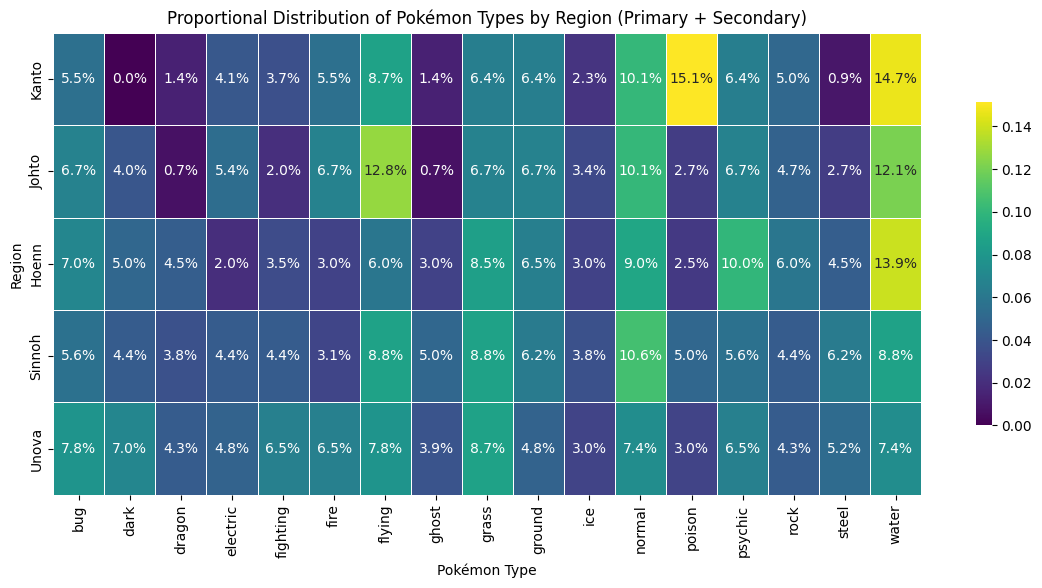

In [13]:
plt.figure(figsize=(14, 6)) # Set a good figure size for 18 columns

# Plot the heatmap using the recommended sequential color map and annotations
sns.heatmap(
    cleaned_types,
    cmap='viridis',      # Sequential color map
    vmin=0,              # Start the scale at 0%
    annot=True,          # Show the percentage number in each cell
    fmt='.1%',           # Format the annotation as a percentage with 1 decimal place
    linewidths=.5,       # Add thin white lines between cells
    cbar_kws={'shrink': 0.7} # Make color bar slightly smaller
)


plt.title('Proportional Distribution of Pokémon Types by Region (Primary + Secondary)')
plt.xlabel('Pokémon Type')
plt.ylabel('Region')
plt.show()

# Analysis
Based on the generated heatmap of proportional type distribution, two key trends emerge:

- **Early Generation Saturation**: The Kanto and Johto regions exhibit the most uneven distributions. Kanto shows strong saturation in Water, Normal, and Poison types, reflecting early game design constraints and thematic choices. Conversely, Dark type shows a $0\%$ presence, confirming its absence in Generation 1. Johto shows high saturation in Flying, Normal, and Water types, while the very low saturation in Dragon and Ghost types reflect their rarities and early-game constraints.
- **Increasing Diversity (Generations 3-5)**: The Hoenn, Sinnoh, and Unova regions demonstrate a visible shift toward diversification. The color intensity across the heatmap becomes less polarized, meaning no single type dominates the region. Unova shows the most uniform distribution, with no type exceeding $7.5\%$ except for the most common types.
- **Consistent Staples**: Types like Water, Normal, and Flying remain proportionally high across nearly all regions, indicating their fundamental role in the Pokémon ecosystem, while types like Dragon and Ghost remain proportionally low, likely to maintain their rarity and strength.

# Conclusion
The analysis confirms that distinct differences in regional ecological signatures exist, particularly when comparing the first generation to later ones. The normalized crosstab clearly illustrates a design evolution: the franchise shifted from regional type saturation (Kanto) to a mandate for increasing proportional type diversity (Unova). The Heatmap served as an essential tool to compare the 90+ individual data points simultaneously, validating the hypothesis that earlier generations relied more heavily on a smaller pool of dominant types than their successors.